# Import modules

In [1]:
# import warnings
# warnings.simplefilter("ignore", UserWarning)

import anndata
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import numpy.random as random
import pandas as pd
import scanpy as sc

import scvi
import os

/home/kk837/.conda/envs/scvi_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import gc
import torch

In [3]:
import session_info
session_info.show()

/home/kk837/.conda/envs/scvi_env/lib/python3.12/site-packages/session_info/main.py:213: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  mod_version = _find_version(mod.__version__)


In [4]:
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.set_figure_params(dpi=80, facecolor='white', color_map = 'RdPu',)

# Variables

In [5]:
data_object_dir = '/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/VisiumHD/Revision_Oct2025'

In [6]:
# create scVI output directories
os.makedirs(f"{data_object_dir}/scVI/models", exist_ok=True)
os.makedirs(f"{data_object_dir}/scVI/latent_variables", exist_ok=True)

# Read in anndata

In [7]:
adata = sc.read_h5ad(f'{data_object_dir}/all_b2c_cells_filtered_raw.h5ad')
adata.obs['coarse_grain_pre'].value_counts()

coarse_grain_pre
VentricularCardiomyocytes    113150
unclassified_mixture          56885
AtrialCardiomyocytes          28423
Mesenchymal                   24717
Endothelium                     863
EpithelialCells                 700
Megakaryocytes                  359
Name: count, dtype: int64

In [8]:
# subset unclassified_mixture cells
adata_sub = adata[adata.obs['coarse_grain_pre']=='unclassified_mixture']
adata_sub.shape

(56885, 18085)

# Run scVI, categorical covariates to correct: donor

##### 3 #####


Anndata setup with scvi-tools version 1.3.3.

Setup via `SCVI.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': 'donor',
│   'labels_key': None,
│   'size_factor_key': None,
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │   3   │
│         n_cells          │ 56885 │
│ n_extra_categorical_covs │   0   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │   1   │
│          n_vars          │ 18085 │
└──────────────────────────┴───────┘

...

Epoch 400/400: 100%|█████████▉| 399/400 [26:27<00:03,  3.96s/it, v_num=1, train_loss_step=3.56e+3, train_loss_epoch=3.47e+3]

Epoch 400/400: 100%|██████████| 400/400 [26:31<00:00,  3.97s/it, v_num=1, train_loss_step=3.56e+3, train_loss_epoch=3.47e+3]

Epoch 400/400: 100%|██████████| 400/400 [26:31<00:00,  3.97s/it, v_num=1, train_loss_step=3.56e+3, train_loss_epoch=3.47e+3]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [26:31<00:00,  3.98s/it, v_num=1, train_loss_step=3.56e+3, train_loss_epoch=3.47e+3]

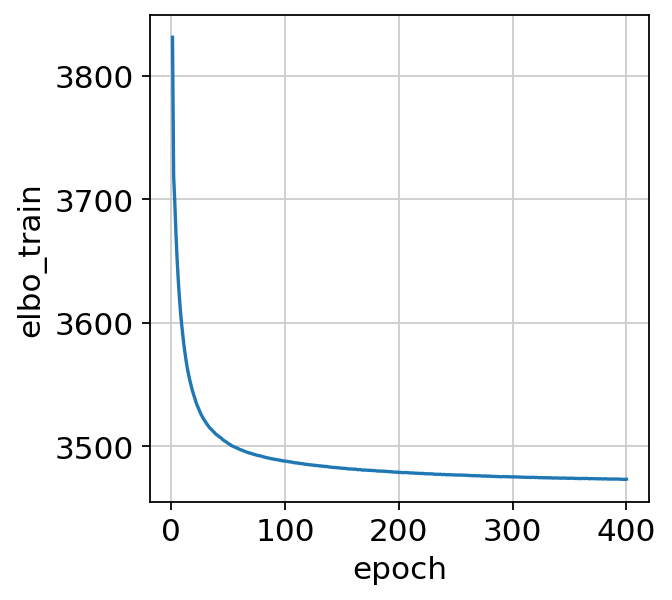

In [9]:
adata_sub = adata_sub.copy()

# Setup anndata for scVI
scvi.model.SCVI.setup_anndata(adata_sub, 
                              # layer="counts", 
                              batch_key="donor", # we want to correct for this 
                              # continuous_covariate_keys=['total_counts','pct_counts_mt','pct_counts_ribo']
                             ) 

# with three n_layer conditions
n_layer_list = [3]

for n_layers in n_layer_list:
    print(f'##### {n_layers} #####')
    # setup
    vae = scvi.model.SCVI(adata_sub, n_hidden = 128, n_latent = 50, n_layers = n_layers, dispersion = 'gene-batch')
    vae.view_anndata_setup(adata_sub)
    # train
    vae.train(max_epochs=400)
    # save trained model
    vae.save(f"{data_object_dir}/scVI/models/unclassified-mixture_correcting-donor_n-layers-{str(n_layers)}/",
             overwrite=True)
    # save latent space
    latent = sc.AnnData(vae.get_latent_representation(),
                    obs=adata_sub.obs.copy())
    # drop all the obs columns, for simplicity
    latent.obs = latent.obs.drop(columns=latent.obs.columns, axis=1)
    latent.write(f'{data_object_dir}/scVI/latent_variables/unclassified-mixture_correcting-donor_n-layers-{str(n_layers)}.h5ad')
    # Convergency plot
    vae.history['elbo_train']
    x = np.linspace(1, (len(vae.history['elbo_train'])), (len(vae.history['elbo_train'])))
    plt.plot(x, vae.history['elbo_train'], label="train")
    plt.xlabel('epoch')
    plt.ylabel('elbo_train')
    plt.show()
    
    del vae
    # free up GPU
    gc.collect()
    torch.cuda.empty_cache()
    print('')